# COMPAS-2X: Random Forest Prediction Experiments

## Overview

This notebook summarises the RF ablation study run by `compas-2/scripts/run_compas2_experiment.py`. The goal is to quantify how much predictive power comes from ring-type identity versus pure topology, using three controlled feature sets on the same 10,000-molecule sample.

Figures and tables were pre-generated by the script and are loaded here for presentation.

In [1]:
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = None

_here = Path().resolve()
if _here.name == 'predictions' and _here.parent.name == 'compas-2':
    ROOT = _here.parent.parent
else:
    ROOT = _here

RESULTS_DIR = ROOT / 'compas-2' / 'predictions' / 'results'
FIG_DIR = RESULTS_DIR
TABLE_DIR = RESULTS_DIR

EXPERIMENT_LABELS = {
    'full_features': 'Full Features',
    'hidden_rings':  'Hidden Ring Types',
    'paper_lalas':   'Paper LFV (aug-LALAS)',
    'baseline':      'Baseline (train mean)',
}

def show_image(filename, width=15):
    path = FIG_DIR / filename
    if Image is not None and display is not None:
        display(Image(filename=str(path), width=int(width * 80)))
        return
    image = plt.imread(path)
    height = width * image.shape[0] / image.shape[1]
    plt.figure(figsize=(width, height))
    plt.imshow(image)
    plt.axis('off')
    plt.close()

## Experimental Setup

### Data
- **Source**: `compas-2x_pastries_features.csv` — 524,318 polycyclic aromatic molecules with up to 10 rings and 11 possible ring types (benzene, pyridine, pyrazine, pyrrole, furan, thiophene, borole, borinine, DiBorinine, Dhydrodiborinine, cyclobutadiene).
- **Sample**: 10,000 molecules drawn at random (seed = 42) — same sample used across all three experiments.
- **Targets**: `homo`, `lumo`, `gap`, `aip`, `aea`, `energy` (all in eV).

### Model
A `RandomForestRegressor` with the following fixed hyperparameters:

| Parameter | Value |
|---|---|
| `n_estimators` | 100 |
| `min_samples_leaf` | 2 |
| `random_state` | 42 |
| `n_jobs` | −1 (all cores) |

No hyperparameter tuning was performed — the goal is a controlled comparison between feature sets, not maximising absolute accuracy.

### Evaluation
- **Cross-validation**: 5-fold repeated 5 times (25 total folds) using `RepeatedKFold`.
- **Metrics reported**: MAE (eV), MAE as % of mean |target|, R², MAE/std (normalised, unitless).
- **Confidence intervals**: 95% CI via t-distribution across the 25 fold scores.
- **Baseline**: predicting the training-set mean for every test molecule (R² ≈ 0 by construction).

### The Three Experiments

| Experiment | Features | Description |
|---|---|---|
| **full_features** | 112 | All extracted features: ring-type counts, positional counts (terminal/middle/branch), topology (L/A ratios, alternation, branching), heteroatom densities, donor/acceptor class counts. |
| **hidden_rings** | 112 | Same feature set, but ring-type identities are masked — all rings relabelled as benzene, heteroatom counts zeroed. Only topology and ring count information survives. |
| **paper_lalas** | 10 | The 10-feature augmented LALAS Feature Vector (aug-LFV) from Fite et al. 2023, Table 1: number of rings, branching points, LAL subsequence count, L-ratio, longest-L run and its degeneracy, upper-A ratio, lower-to-upper-A ratio, longest upper-A, longest A (case-insensitive). |

## Overall Performance: Normalised MAE

Average MAE/std across all six targets (lower is better). This single-number summary is analogous to Figure 3 (top row) in Fite et al. 2023 and allows a clean experiment-level comparison independent of property scale.

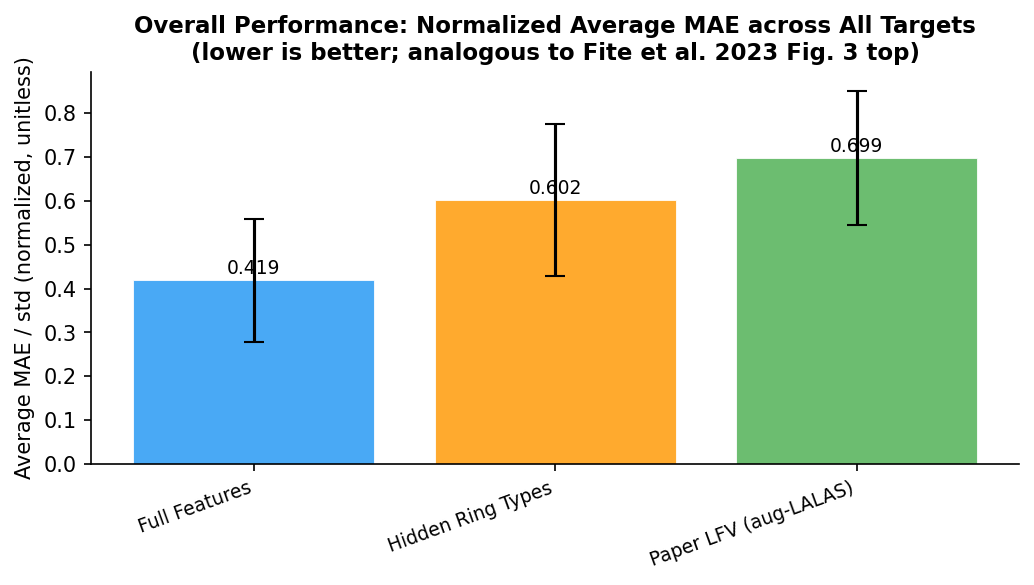

In [2]:
show_image('normalized_mae_summary.png', width=9)

## MAE by Target (eV)

Absolute MAE per target with 95% CI. The baseline bar (train mean) is the same across all experiments. All targets are in eV.

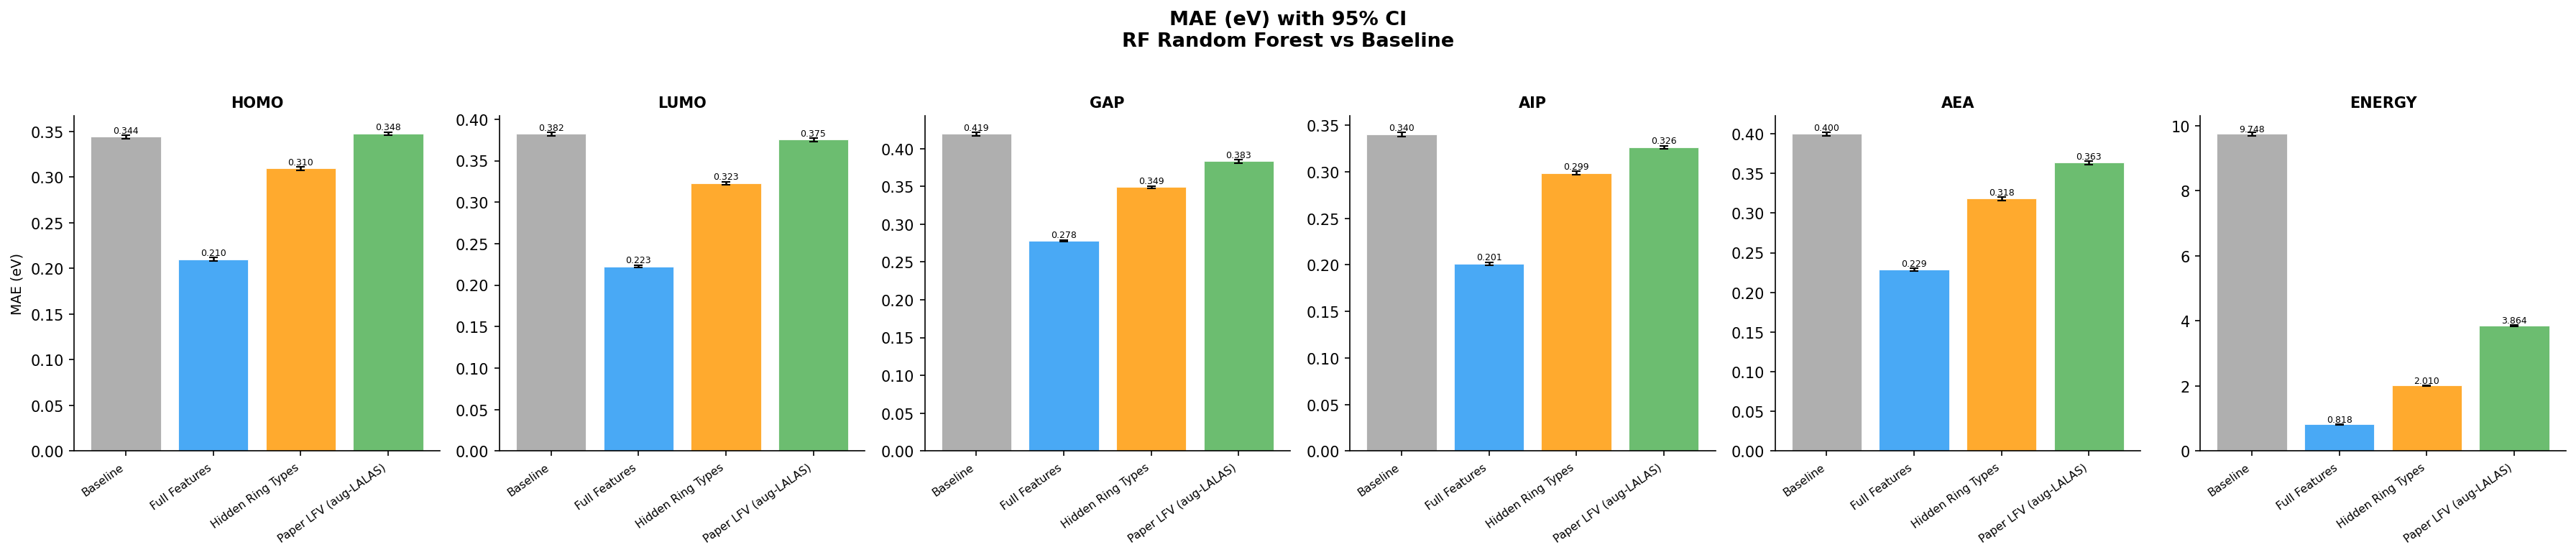

In [3]:
show_image('mae_absolute_by_target.png', width=16)

## MAE by Target (% of mean |target|)

MAE expressed as a percentage of the mean absolute target value. This normalises for the different scales of each property and makes it easier to compare prediction difficulty across targets.

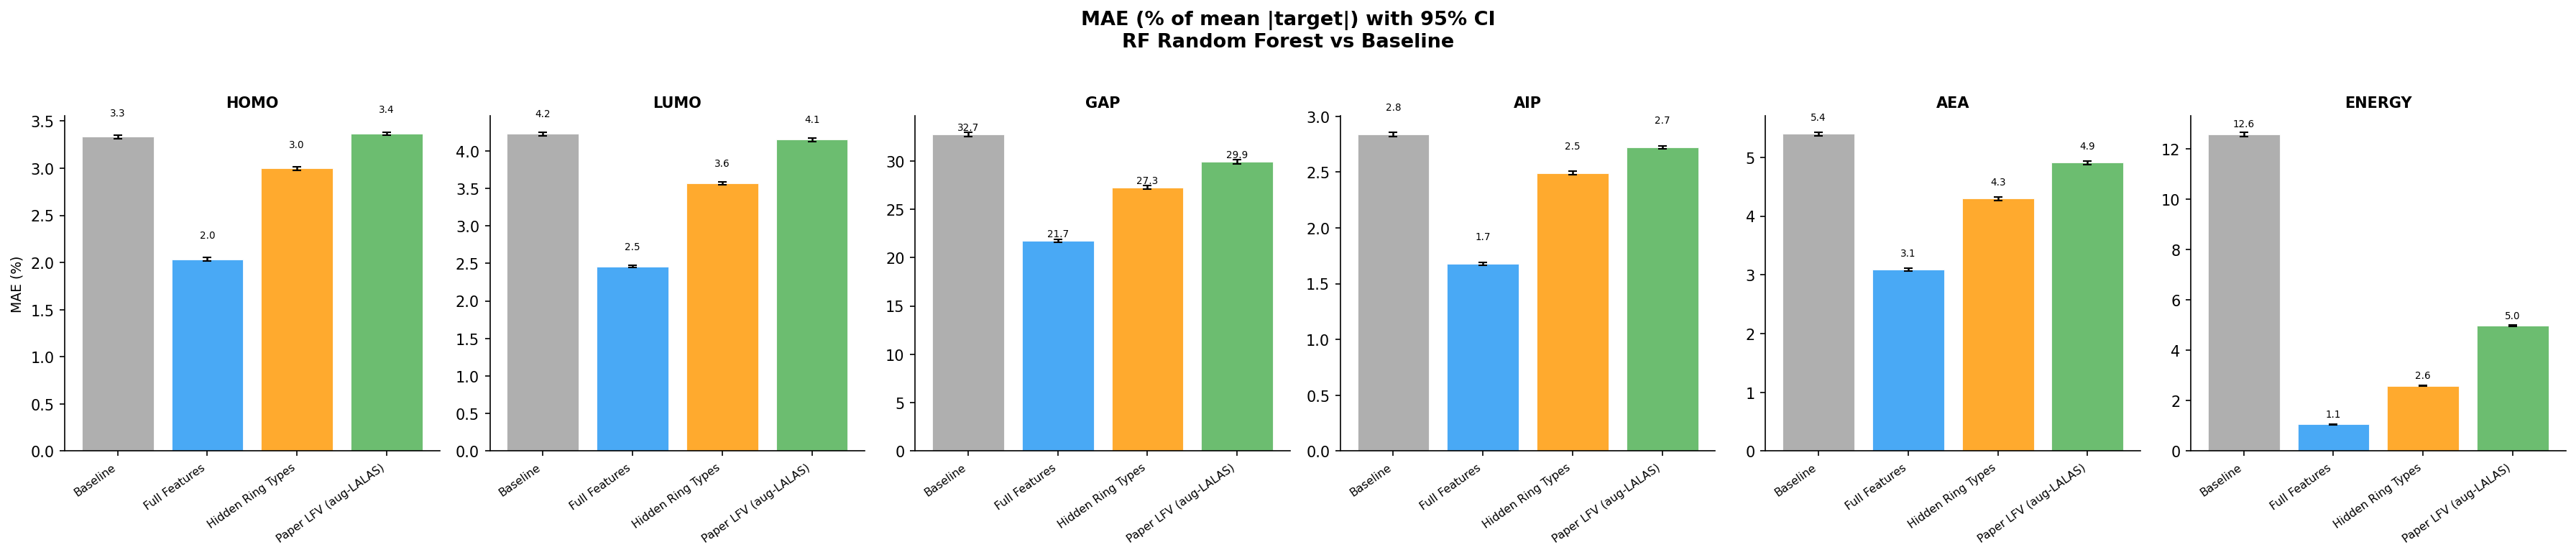

In [4]:
show_image('mae_percent_by_target.png', width=16)

## R² by Target

R² (coefficient of determination) per target. A value of 1.0 is a perfect fit; 0.0 matches the baseline (train mean); negative values are worse than the baseline.

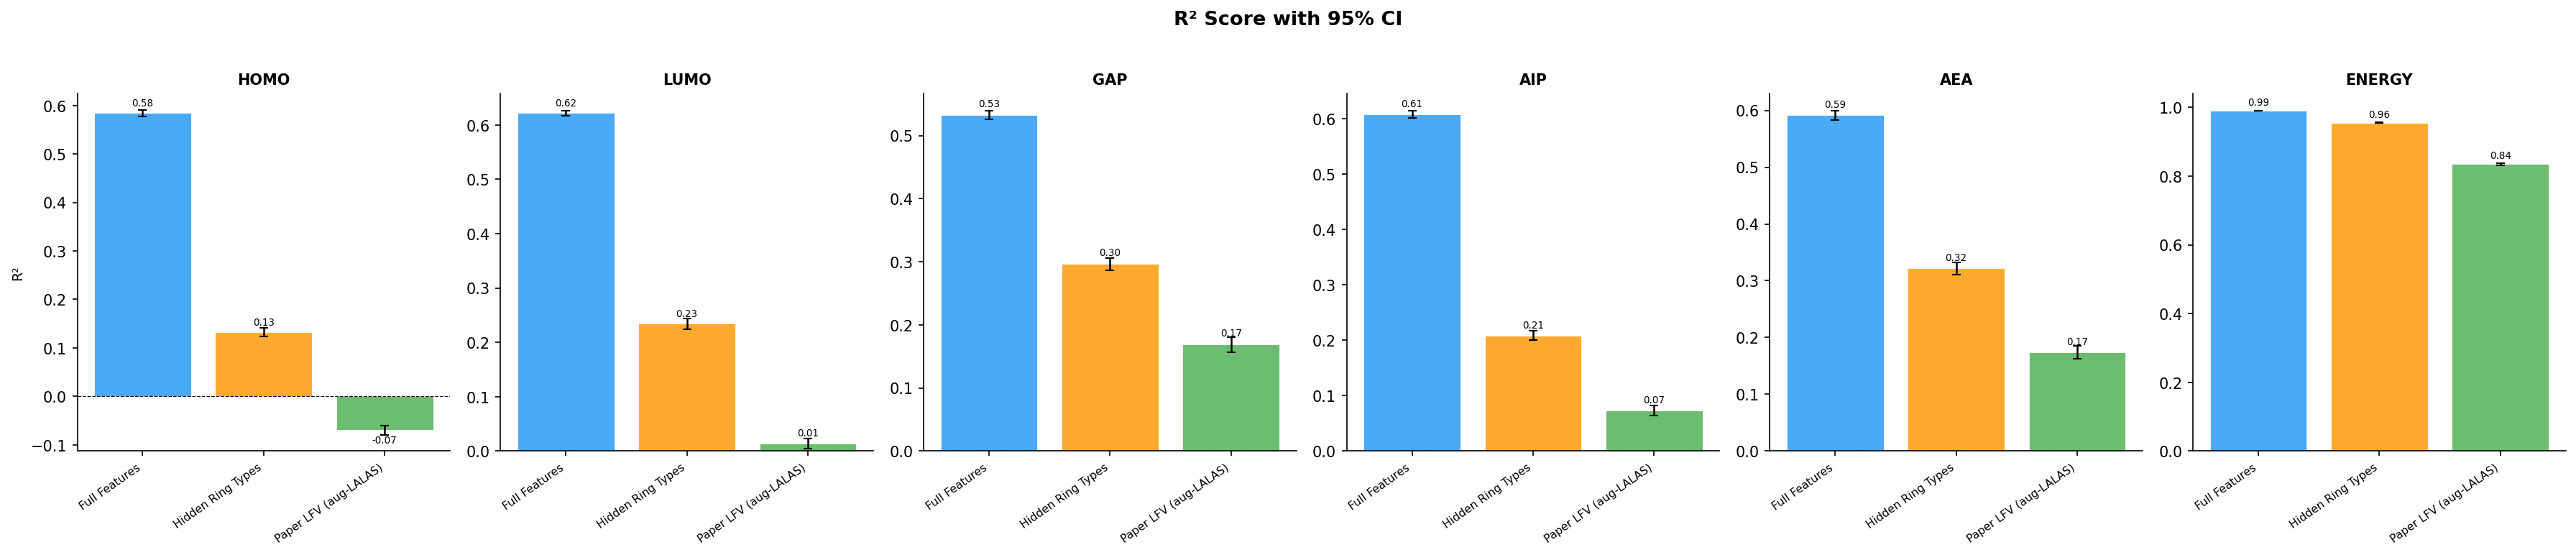

In [5]:
show_image('r2_by_target.png', width=16)

## Full Features vs. Hidden Ring Types

Direct comparison of the two topology experiments. The gap between the two bars quantifies how much ring-type identity (heterocycle species, donor/acceptor class) contributes beyond pure topology for each target.

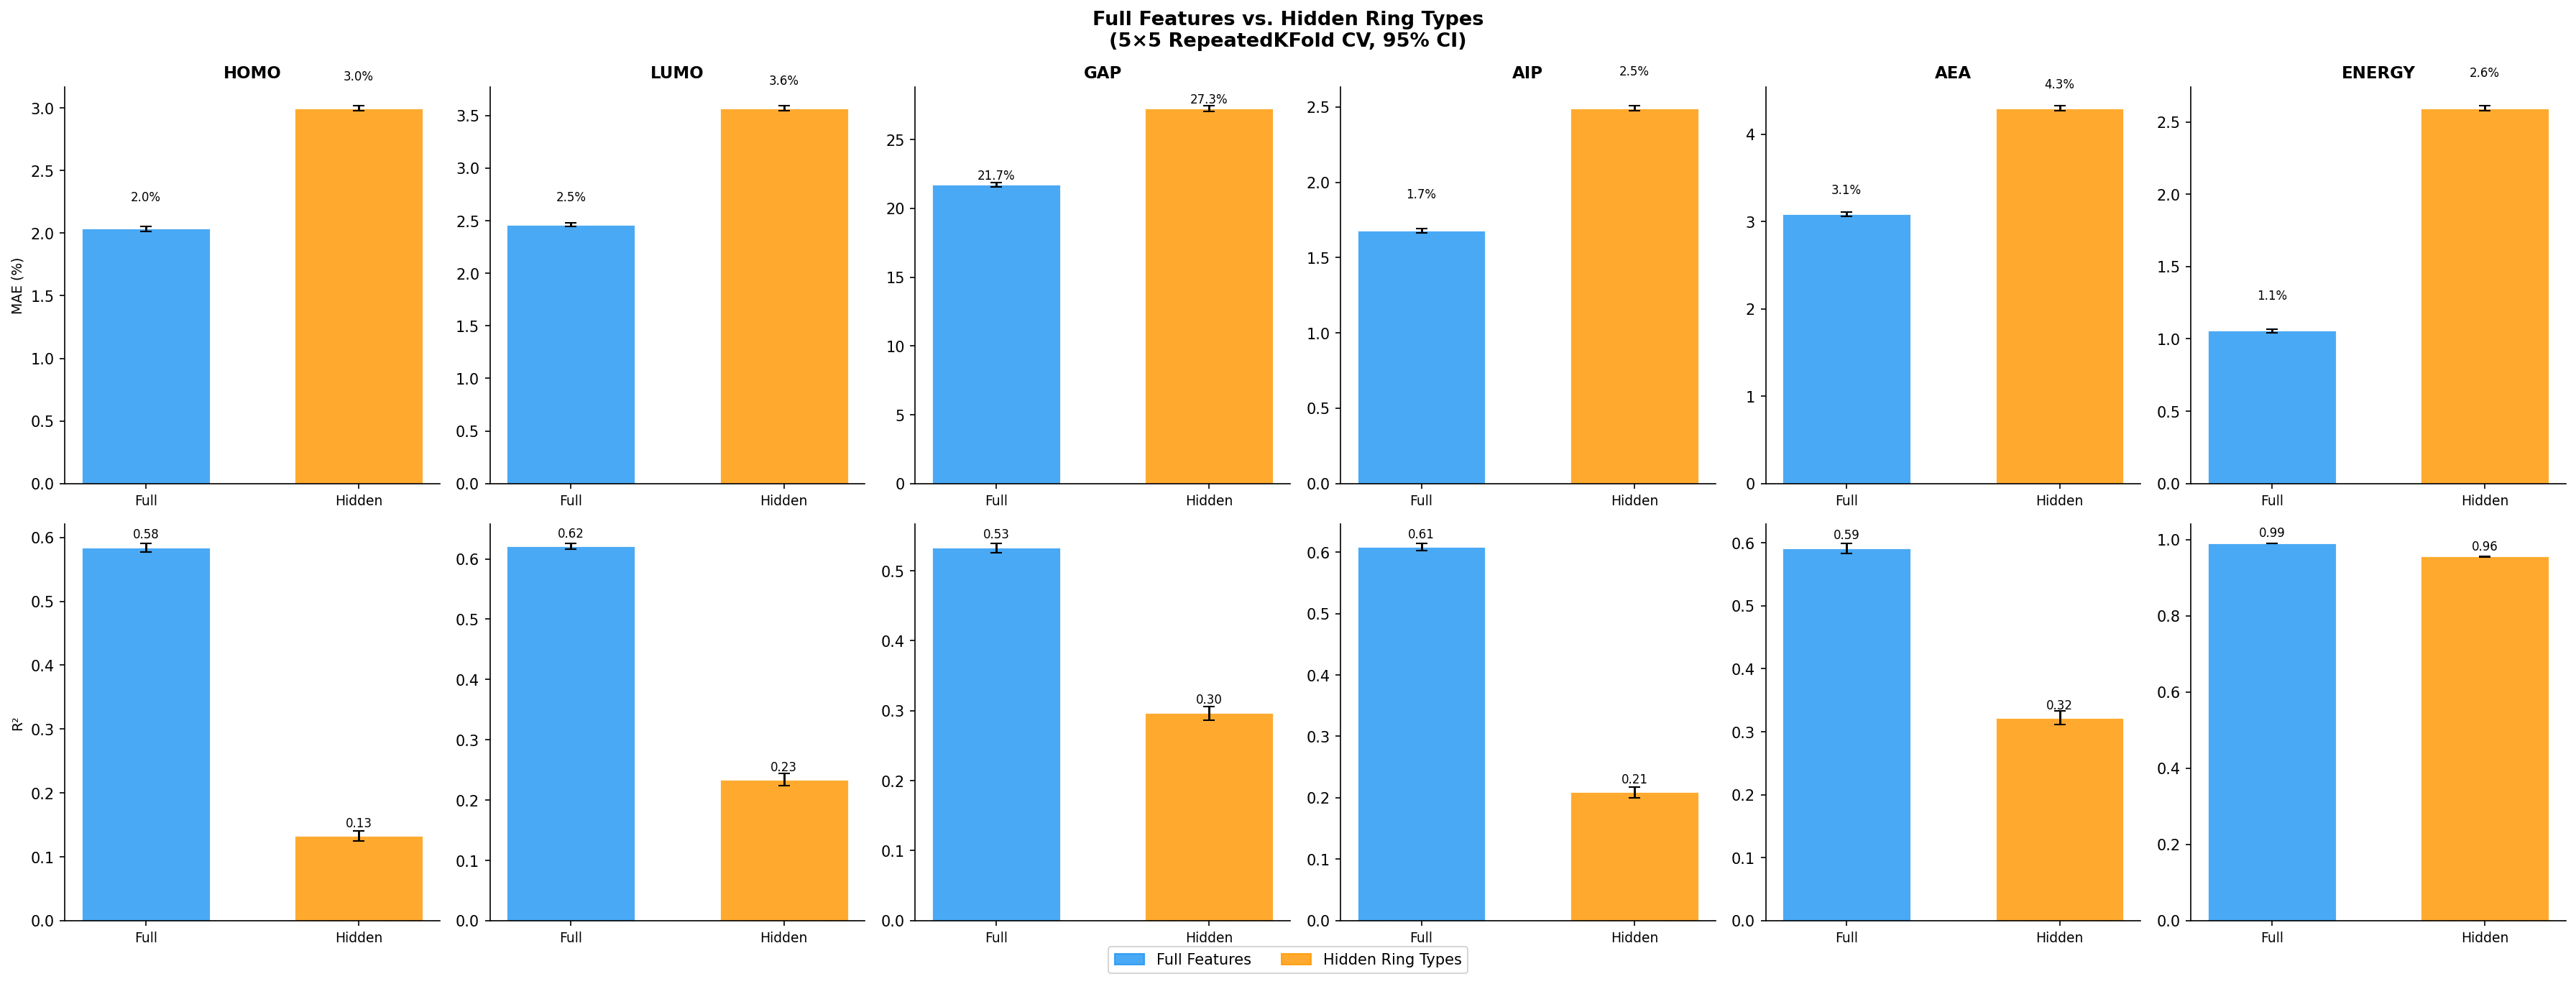

In [6]:
show_image('full_vs_hidden_comparison.png', width=16)

## Feature Importances

Mean RF feature importance (± std) across all 25 CV folds, top 15 features per target. Shown separately for `full_features` (ring identity visible) and `hidden_rings` (ring identity masked).

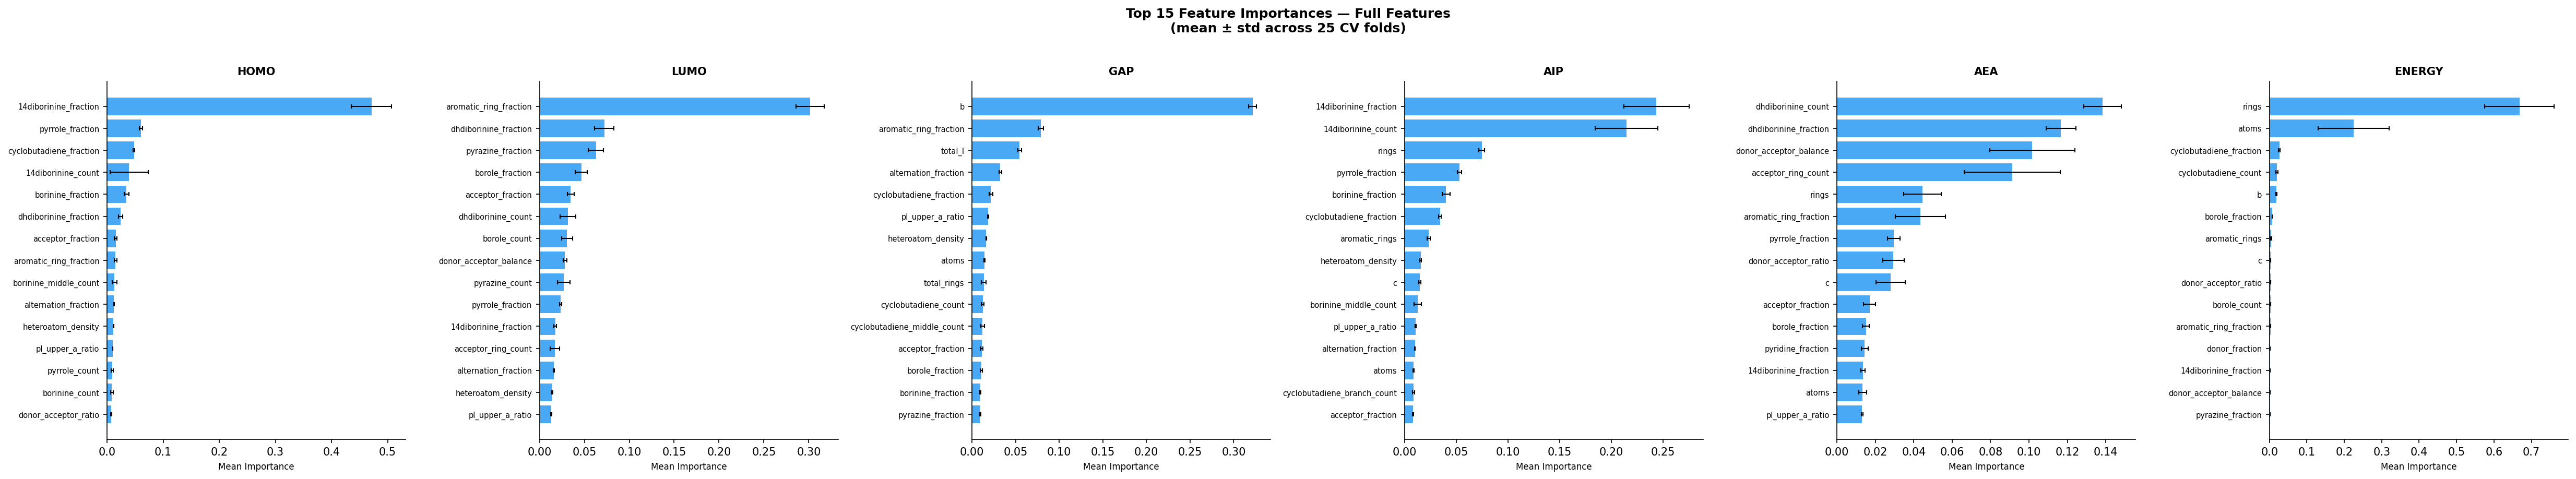

In [12]:
show_image('top_features_full_features.png', width=18)

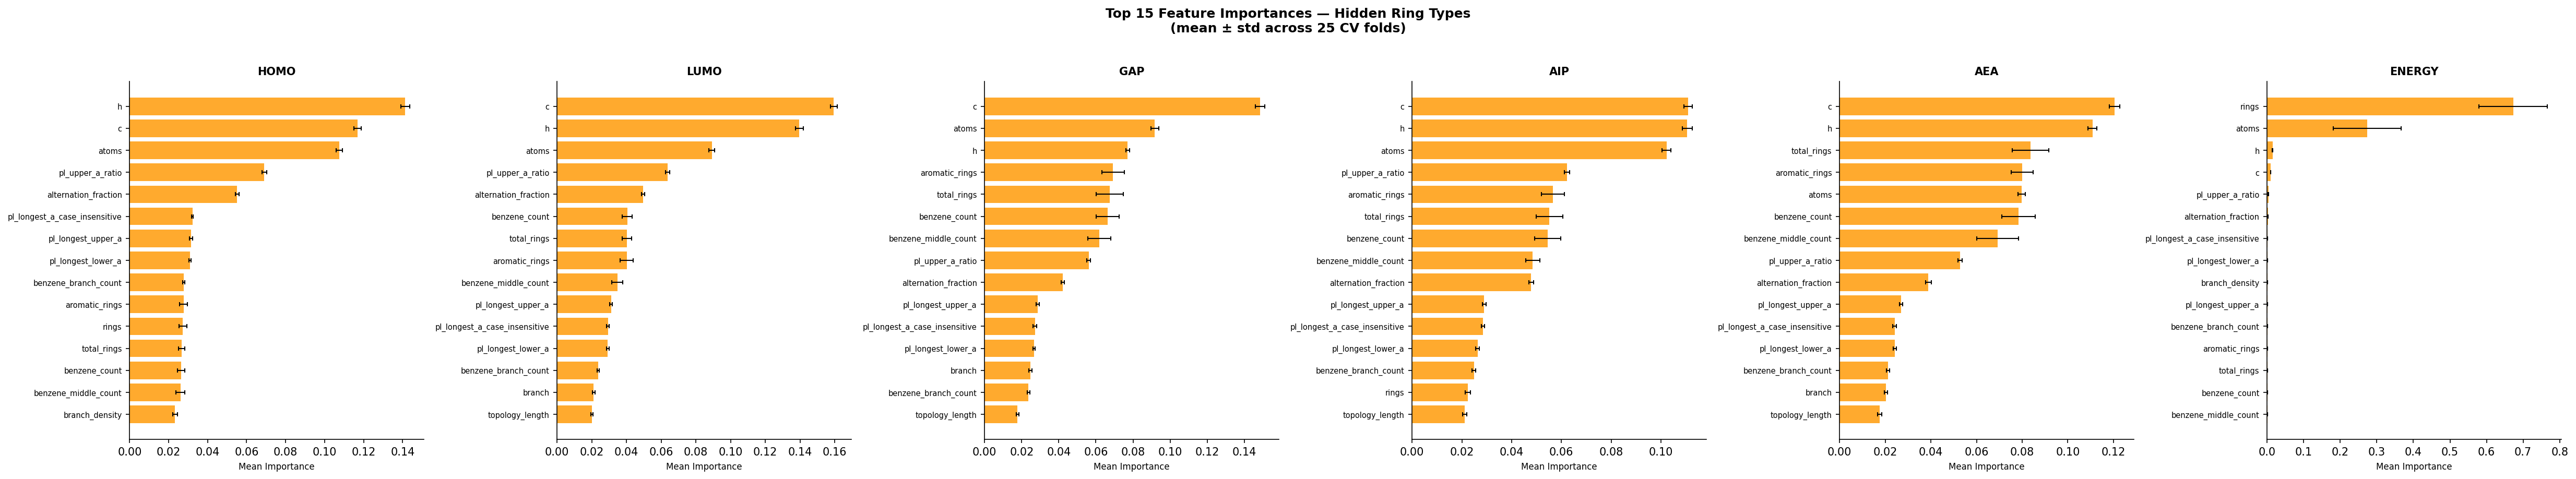

In [8]:
show_image('top_features_hidden_rings.png', width=18)

## Results Summary Table

Wide-format table with MAE (eV), MAE (%), R², and MAE/std for every experiment × target combination, including 95% CI.

In [9]:
summary = pd.read_csv(TABLE_DIR / 'results_summary_table.csv')
summary

,target,baseline_mae_mean,baseline_mae_ci95,baseline_mae_pct_mean,full_features_mae_mean,full_features_mae_mean_ci95,full_features_mae_pct_mean,full_features_mae_pct_mean_ci95,full_features_r2_mean,full_features_r2_mean_ci95,...,hidden_rings_mae_std_mean,hidden_rings_mae_std_mean_ci95,paper_lalas_mae_mean,paper_lalas_mae_mean_ci95,paper_lalas_mae_pct_mean,paper_lalas_mae_pct_mean_ci95,paper_lalas_r2_mean,paper_lalas_r2_mean_ci95,paper_lalas_mae_std_mean,paper_lalas_mae_std_mean_ci95
0,homo,0.3443,"[0.3423, 0.3463]",3.33,0.2101,"[0.2080, 0.2122]",2.0340,"[2.0135, 2.0546]",0.5844,"[0.5775, 0.5912]",...,0.7491,"[0.7451, 0.7532]",0.3480,"[0.3465, 0.3496]",3.3698,"[3.3545, 3.3851]",-0.0701,"[-0.0794, -0.0607]",0.8423,"[0.8383, 0.8463]"
1,lumo,0.3825,"[0.3803, 0.3847]",4.23,0.2226,"[0.2212, 0.2240]",2.4603,"[2.4446, 2.4761]",0.6216,"[0.6168, 0.6263]",...,0.6943,"[0.6893, 0.6993]",0.3754,"[0.3733, 0.3775]",4.1497,"[4.1268, 4.1725]",0.0142,"[0.0051, 0.0233]",0.8071,"[0.8028, 0.8114]"
2,gap,0.4193,"[0.4165, 0.4221]",32.75,0.2781,"[0.2768, 0.2794]",21.7214,"[21.5808, 21.8620]",0.5327,"[0.5257, 0.5397]",...,0.6729,"[0.6679, 0.6779]",0.3831,"[0.3811, 0.3851]",29.9231,"[29.7206, 30.1256]",0.1689,"[0.1569, 0.1810]",0.7388,"[0.7337, 0.7439]"
3,aip,0.3402,"[0.3376, 0.3428]",2.84,0.2011,"[0.1993, 0.2030]",1.6781,"[1.6627, 1.6935]",0.6083,"[0.6019, 0.6146]",...,0.7006,"[0.6965, 0.7047]",0.3263,"[0.3245, 0.3281]",2.7222,"[2.7070, 2.7373]",0.0732,"[0.0636, 0.0829]",0.7655,"[0.7613, 0.7697]"
4,aea,0.3999,"[0.3975, 0.4023]",5.40,0.2286,"[0.2267, 0.2305]",3.0869,"[3.0613, 3.1124]",0.5916,"[0.5834, 0.5997]",...,0.6298,"[0.6241, 0.6354]",0.3635,"[0.3614, 0.3655]",4.9081,"[4.8814, 4.9348]",0.1739,"[0.1623, 0.1854]",0.7192,"[0.7144, 0.7239]"
5,energy,9.7481,"[9.6858, 9.8103]",12.58,0.8181,"[0.8092, 0.8270]",1.0557,"[1.0439, 1.0676]",0.9906,"[0.9903, 0.9909]",...,0.1655,"[0.1638, 0.1672]",3.8639,"[3.8409, 3.8869]",4.9861,"[4.9562, 5.0159]",0.8353,"[0.8318, 0.8387]",0.3182,"[0.3153, 0.3211]"


## Key Findings

1. **Ring-type identity is the dominant signal for electronic targets.** Full features (112) consistently outperform hidden rings (112, masked) for HOMO, LUMO, AIP, and AEA — properties that are exquisitely sensitive to which heteroatom species is present.

2. **Topology alone still beats the baseline.** Hidden rings achieves R² > 0 on all targets, confirming that pure structural topology (L/A annotation pattern, branch count, ring count) carries real predictive information — consistent with the paper's claim.

3. **The 10-feature paper LFV (aug-LALAS) is insufficient for electronic targets on this dataset.** Paper LFV R² is at or below zero for HOMO and LUMO. The 10 summary statistics compress topology too aggressively and cannot distinguish ring types — a critical limitation on the chemically diverse COMPAS-2X dataset (11 ring types including antiaromatic and exotic boron rings).

4. **Energy is the easiest target.** All three feature sets achieve high R² for `energy`, because molecular energy scales predictably with ring count and composition regardless of fine electronic structure.

5. **Gap is the hardest target.** Its range spans 0.003–3.8 eV (nearly three orders of magnitude), driven by the mix of aromatic and antiaromatic rings. Even full features leaves substantial unexplained variance.

## Benzene-Only Validation: Paper LFV on a Homogeneous Subset

The full COMPAS-2X experiment showed that the 10 paper LFV features fail on electronic targets (R² ≈ 0 or negative for HOMO/LUMO). The question is whether this is a problem with the features themselves, or with applying them to a chemically diverse dataset they were not designed for.

To test this, we filter COMPAS-2X to **pure carbocyclic PAH molecules** — those containing only benzene rings and no heteroatom-containing rings — and repeat the RF experiment with the same 10 LFV features.

**Why this matters:** If topology is genuinely the dominant structural variable (as it is in all-carbon PAHs), the 10 features should be sufficient. COMPAS-2X contains 799 such molecules, all used here.

> **Note:** All 799 benzene-only molecules are used (no random subsampling needed). The same 5×5 RepeatedKFold CV and RF configuration are applied.

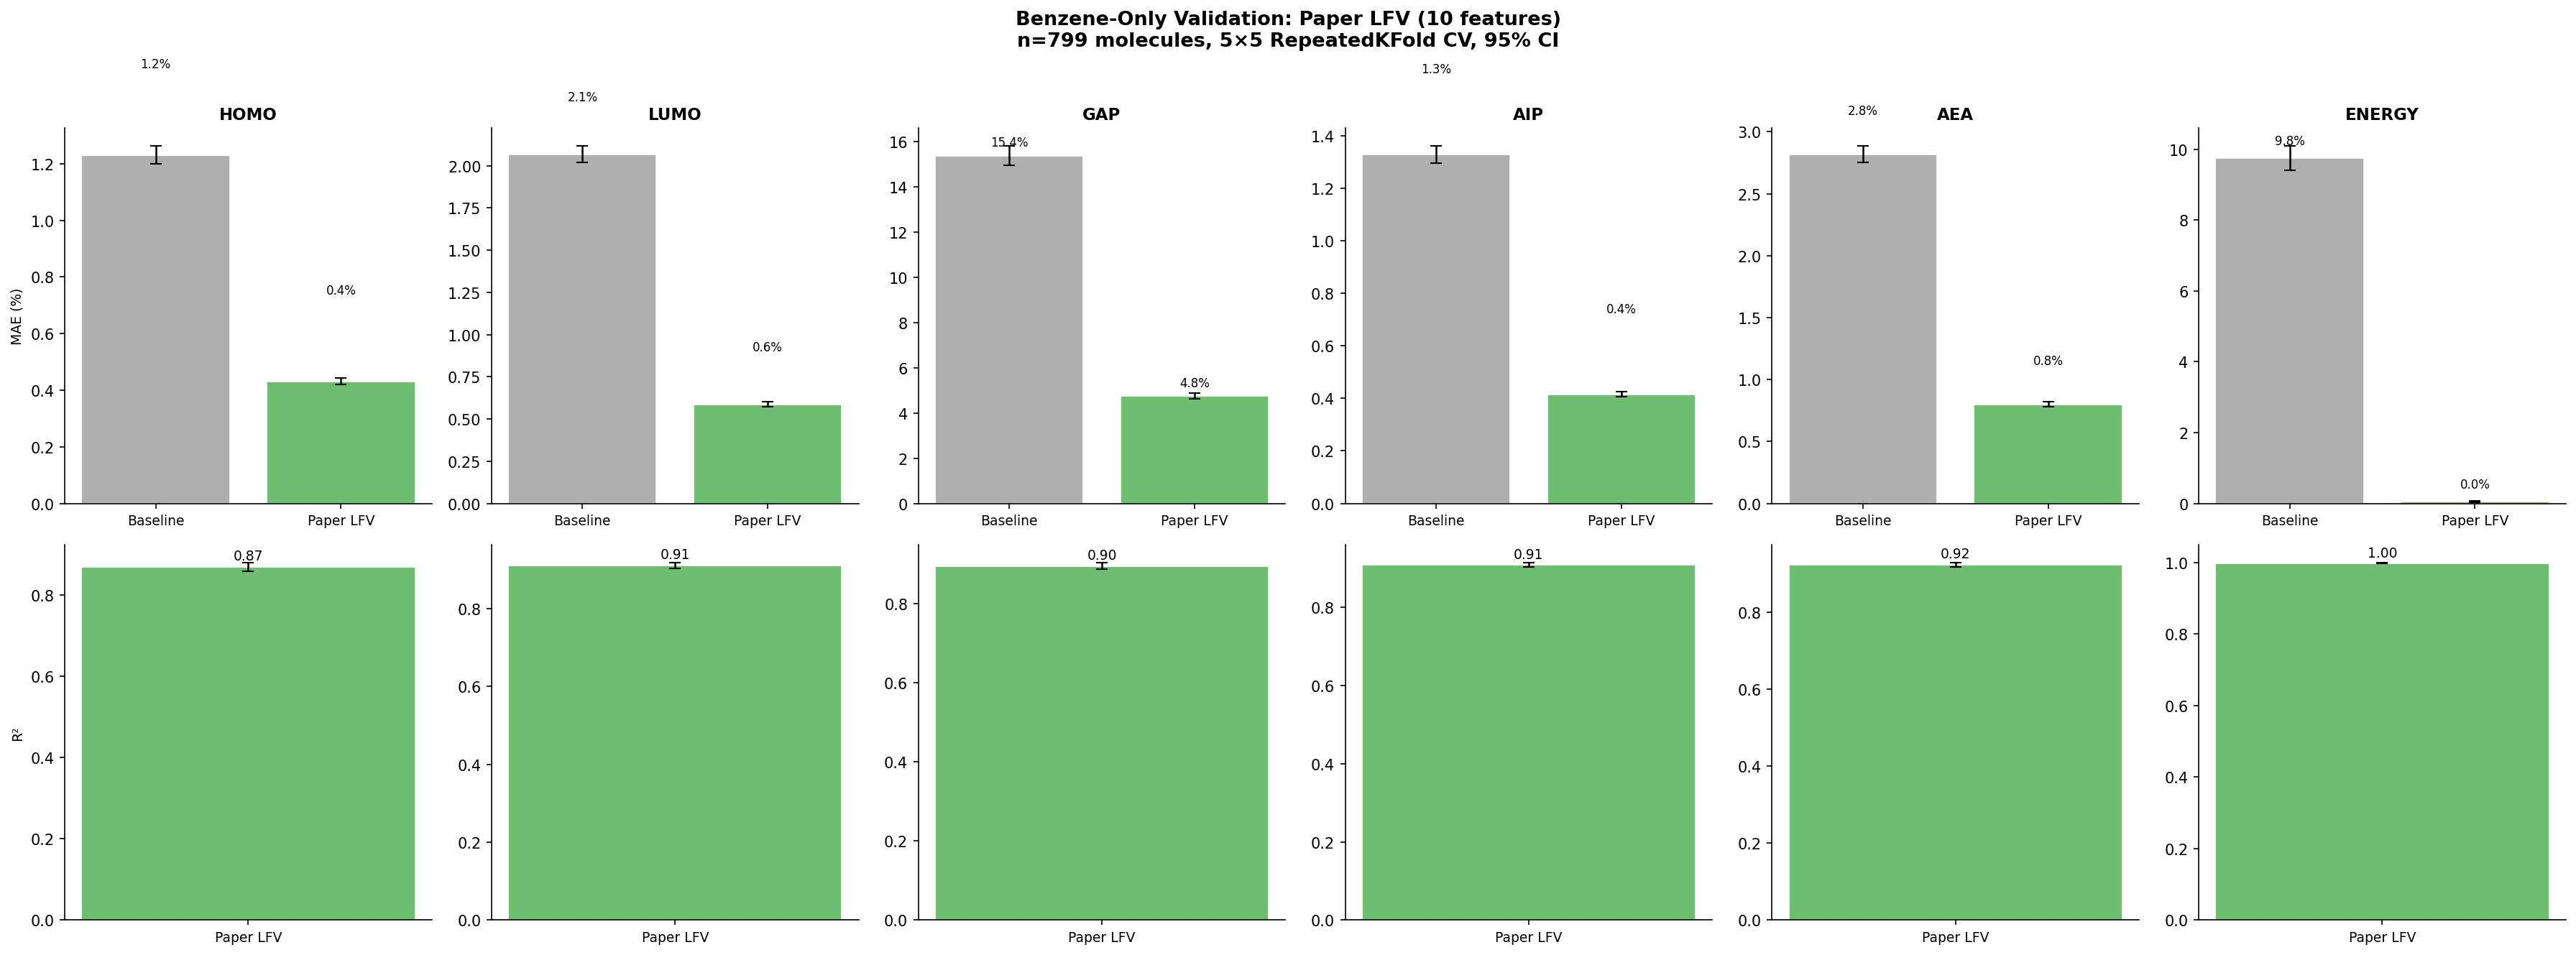

In [10]:
show_image('benzene_only_paper_lfv_results.png', width=16)

In [11]:
benz_summary = pd.read_csv(TABLE_DIR / 'benzene_only_summary.csv')
benz_summary

,target,n_molecules,baseline_mae,baseline_mae_pct,paper_lfv_mae,paper_lfv_mae_ci95,paper_lfv_mae_pct,paper_lfv_r2
0,homo,799,0.1318,1.23,0.0462,"[0.0449, 0.0474]",0.43,0.8694
1,lumo,799,0.1796,2.07,0.0510,"[0.0496, 0.0523]",0.59,0.9107
2,gap,799,0.3100,15.38,0.0958,"[0.0931, 0.0985]",4.75,0.8957
3,aip,799,0.1629,1.33,0.0510,"[0.0499, 0.0521]",0.42,0.9084
4,aea,799,0.2012,2.82,0.0571,"[0.0557, 0.0585]",0.80,0.9227
5,energy,799,8.2292,9.75,0.0403,"[0.0257, 0.0549]",0.05,0.9981


### Interpretation

The validation confirms the hypothesis:

| Target | R² (full COMPAS-2X, paper LFV) | R² (benzene-only, paper LFV) |
|--------|-------------------------------|------------------------------|
| HOMO   | −0.07                         | **0.87**                     |
| LUMO   | +0.01                         | **0.91**                     |
| GAP    | +0.17                         | **0.90**                     |
| AIP    | +0.07                         | **0.91**                     |
| AEA    | +0.17                         | **0.92**                     |
| Energy | +0.84                         | **0.998**                    |

On the benzene-only subset — where all rings are identical and **topology is the only structural variable** — the 10 LFV features are highly predictive across all targets (R² 0.87–0.92 for electronic properties, MAE < 0.10 eV).

This directly validates the paper's claim. The failure on the full COMPAS-2X dataset is not a flaw in the LFV features: it is a consequence of applying a topology-only descriptor to a dataset where **11 chemically distinct ring types** (including antiaromatic and exotic boron rings) dominate the variance in HOMO/LUMO. Once chemical diversity is removed, topology recovers its predictive power.